In [2]:
# =============================================================================
# SETUP: Imports, loader de embeddings por segmento y config base
# =============================================================================
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV, cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, make_scorer, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")

EMBEDDINGS_ROOT = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Depresión/embeddings_v2"
CONDITION = "depresion"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]
N_SPLITS = 5

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def _load_from_manifest(manifest_path: Path, model_key: str, condition: str):
    with open(manifest_path) as f:
        manifest = json.load(f)
    entries = [
        m for m in manifest
        if m.get("model") == model_key and m.get("condition") == condition
    ]
    if not entries:
        return None

    X_rows, y_rows, group_rows = [], [], []
    for e in entries:
        with open(e["file"]) as f:
            record = json.load(f)
        X_rows.append(np.array(record["embedding"], dtype=np.float32))
        y_rows.append(int(record["class_id"]))
        group_rows.append(record["audio_id"])

    return np.stack(X_rows), np.array(y_rows), np.array(group_rows)

def _load_from_tree(embeddings_root: str, model_key: str, condition: str):
    base = Path(embeddings_root) / condition
    if not base.exists():
        raise FileNotFoundError(f"No existe la carpeta: {base}")

    pattern = f"class_*/{model_key}/*/segment_*/embedding.json"
    paths = list(base.glob(pattern))
    if not paths:
        raise FileNotFoundError(
            f"No se encontraron embeddings con el patrón: {base / pattern}"
        )

    X_rows, y_rows, group_rows = [], [], []
    for p in paths:
        with open(p) as f:
            record = json.load(f)
        X_rows.append(np.array(record["embedding"], dtype=np.float32))
        y_rows.append(int(record["class_id"]))
        group_rows.append(record["audio_id"])

    return np.stack(X_rows), np.array(y_rows), np.array(group_rows)

def load_segment_embeddings(embeddings_root: str, model_key: str, condition: str):
    """
    Carga embeddings por segmento y retorna (X, y, groups).
    groups corresponde a audio_id para GroupKFold.
    """
    manifest_path = Path(embeddings_root) / "manifest.json"
    if manifest_path.exists():
        loaded = _load_from_manifest(manifest_path, model_key, condition)
        if loaded is not None:
            return loaded

    return _load_from_tree(embeddings_root, model_key, condition)

In [3]:
# ==============================================================================
# CELDA 1: Evaluacion con embeddings usando LazyClassifier SIN SMOTE
# (Solo class_weight='balanced' en modelos que lo soporten)
# GroupKFold usando audio_id como grupo
# ==============================================================================
resultados_globales_no_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model} (SIN SMOTE)")
    print(f"{'='*80}")

    try:
        X, y, groups = load_segment_embeddings(EMBEDDINGS_ROOT, emb_model, CONDITION)
        print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = GroupKFold(n_splits=N_SPLITS)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)
    for _, model in clf.models.items():
        if hasattr(model, 'class_weight'):
            model.class_weight = 'balanced'

    rows = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        y_tr = y[tr_idx]
        y_val = y[val_idx]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
            print(f"  Fold {fold}: omitido (solo una clase).")
            continue

        X_tr, X_val = X[tr_idx], X[val_idx]
        models_fold, _ = clf.fit(X_tr, X_val, y_tr, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)

    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"

        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model}:")
        print(cv_summary.head(5).to_string(index=False))

        resultados_globales_no_smote.append(cv_summary)

if resultados_globales_no_smote:
    res_final_no_smote = pd.concat(resultados_globales_no_smote, ignore_index=True)
    res_final_no_smote = res_final_no_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (SIN SMOTE)")
    print(f"{'='*80}")
    print(res_final_no_smote.head(15).to_string(index=False))


EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m (SIN SMOTE)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Shape de X: (5252, 1024), Shape de y: (5252,)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para xlsr-300m:
Embedding_Model                       Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m PassiveAggressiveClassifier  0.633821           0.549694  0.634896  0.543720 0.565803
      xlsr-300m          LogisticRegression  0.646126           0.536159  0.637324  0.533795 0.560487
      xlsr-300m                   LinearSVC  0.633584           0.533955  0.630752  0.531859 0.557691
      xlsr-300m  LinearDiscriminantAnalysis  0.636123           0.532412  0.631347  0.530244 0.559901
      xlsr-300m             RidgeClassifier  0.649066           0.532253  0.636826  0.529637 0.561499

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53 (SIN SMOTE)


...


Top 5 clasificadores para wavlm-large:
Embedding_Model                      Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large        ExtraTreeClassifier  0.609085           0.514493  0.611453  0.512765 0.514493
    wavlm-large                 Perceptron  0.608433           0.510233  0.607751  0.506863 0.524911
    wavlm-large         LogisticRegression  0.630261           0.510366  0.617807  0.506289 0.521284
    wavlm-large                  LinearSVC  0.626464           0.508330  0.616254  0.505434 0.518321
    wavlm-large LinearDiscriminantAnalysis  0.625728           0.504264  0.613282  0.500103 0.517490

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large (SIN SMOTE)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.


Shape de X: (5252, 1024), Shape de y: (5252,)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para hubert-large:
Embedding_Model              Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large         Perceptron  0.609165           0.531630  0.613600  0.523778 0.547496
   hubert-large      SGDClassifier  0.607963           0.520934  0.612018  0.517684 0.531875
   hubert-large LogisticRegression  0.644638           0.517418  0.625862  0.511531 0.548287
   hubert-large          LinearSVC  0.630151           0.515434  0.619187  0.510907 0.541880
   hubert-large    RidgeClassifier  0.647276           0.515375  0.625592  0.508522 0.537335

RANKING GLOBAL DE MODELOS DE EMBEDDINGS (SIN SMOTE)
      Embedding_Model                       Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust PassiveAggressiveClassifier  0.627720           0.551181  0.632586  0.545471 0.569486
            xlsr-300m PassiveAggressiveClassifier  0.633821           0.549694  0.634896  0.543720 0.565803
            xlsr-300m   

In [4]:
# ==============================================================================
# CELDA 2: Evaluacion con embeddings usando LazyClassifier CON SMOTE
# (SMOTE aplicado SOLO en el conjunto de TRAIN del CV)
# GroupKFold usando audio_id como grupo
# ==============================================================================
resultados_globales_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model} (CON SMOTE en TRAIN)")
    print(f"{'='*80}")

    try:
        X, y, groups = load_segment_embeddings(EMBEDDINGS_ROOT, emb_model, CONDITION)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = GroupKFold(n_splits=N_SPLITS)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        y_tr = y[tr_idx]
        y_val = y[val_idx]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
            print(f"  Fold {fold}: omitido (solo una clase).")
            continue

        X_tr, X_val = X[tr_idx], X[val_idx]

        k = min(5, int(pd.Series(y_tr).value_counts().min()) - 1)
        if k >= 1:
            X_tr, y_tr = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr, y_tr)

        models_fold, _ = clf.fit(X_tr, X_val, y_tr, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)

    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"

        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (CON SMOTE):")
        print(cv_summary.head(5).to_string(index=False))

        resultados_globales_smote.append(cv_summary)

if resultados_globales_smote:
    res_final_smote = pd.concat(resultados_globales_smote, ignore_index=True)
    res_final_smote = res_final_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON SMOTE)")
    print(f"{'='*80}")
    print(res_final_smote.head(15).to_string(index=False))


EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m (CON SMOTE en TRAIN)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para xlsr-300m (CON SMOTE):
Embedding_Model              Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m  RidgeClassifierCV  0.591521           0.554721  0.610378  0.539518 0.568644
      xlsr-300m LogisticRegression  0.595269           0.548491  0.612077  0.536878 0.562524
      xlsr-300m                SVC  0.650270           0.539534  0.639650  0.536320 0.566360
      xlsr-300m    RidgeClassifier  0.586032           0.547451  0.604988  0.533015 0.566404
      xlsr-300m              NuSVC  0.654030           0.534431  0.638467  0.530334 0.557171

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53 (CON SMOTE en TRAIN)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para xlsr-53 (CON SMOTE):
Embedding_Model              Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
        xlsr-53                SVC  0.601576           0.558198  0.618060  0.545419 0.583197
        xlsr-53              NuSVC  0.622166           0.541074  0.627195  0.537727 0.559803
        xlsr-53  RidgeClassifierCV  0.580416           0.539222  0.599668  0.526791 0.541172
        xlsr-53 LogisticRegression  0.583980           0.537046  0.601947  0.526581 0.549059
        xlsr-53 AdaBoostClassifier  0.564647           0.541327  0.586541  0.521890 0.555116

EVALUANDO EMBEDDINGS DEL MODELO: whisper-large-encoder (CON SMOTE en TRAIN)


...


Top 5 clasificadores para wav2vec2-large-robust (CON SMOTE):
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust                    SVC  0.625277           0.549079  0.630513  0.543146 0.584143
wav2vec2-large-robust                  NuSVC  0.638212           0.533509  0.631647  0.530548 0.565967
wav2vec2-large-robust     AdaBoostClassifier  0.591217           0.542277  0.605529  0.529180 0.566035
wav2vec2-large-robust RandomForestClassifier  0.680173           0.535820  0.647243  0.527357 0.578211
wav2vec2-large-robust     LogisticRegression  0.577626           0.529187  0.593706  0.517000 0.540025

EVALUANDO EMBEDDINGS DEL MODELO: wavlm-large (CON SMOTE en TRAIN)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para wavlm-large (CON SMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large                    SVC  0.652259           0.524512  0.631399  0.517450 0.553741
    wavlm-large      BaggingClassifier  0.650358           0.517627  0.628792  0.511662 0.519851
    wavlm-large                  NuSVC  0.657057           0.518466  0.629340  0.509062 0.545385
    wavlm-large DecisionTreeClassifier  0.571527           0.511637  0.587229  0.504384 0.511637
    wavlm-large RandomForestClassifier  0.688260           0.521689  0.639048  0.503359 0.542773

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large (CON SMOTE en TRAIN)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para hubert-large (CON SMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large                  NuSVC  0.625177           0.531023  0.623454  0.526471 0.540755
   hubert-large          SGDClassifier  0.567492           0.540719  0.589161  0.521814 0.546334
   hubert-large CalibratedClassifierCV  0.582748           0.531343  0.598596  0.520419 0.544321
   hubert-large                    SVC  0.589420           0.528614  0.601887  0.519427 0.543064
   hubert-large     LogisticRegression  0.571139           0.529954  0.589739  0.515799 0.549303

RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON SMOTE)
      Embedding_Model                      Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
              xlsr-53                        SVC  0.601576           0.558198  0.618060  0.545419 0.583197
wav2vec2-large-robust                        SVC  0.625277           0.549079  0.630513  0.543146 

In [5]:
# ==============================================================================
# CELDA: Evaluacion con embeddings usando LazyClassifier
# Pipeline: StandardScaler -> SMOTE (solo en el conjunto de TRAIN del CV) -> LazyClassifier
# GroupKFold usando audio_id como grupo
# ==============================================================================
resultados_globales_scaler_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model}")
    print(f"Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier")
    print(f"{'='*80}")

    try:
        X, y, groups = load_segment_embeddings(EMBEDDINGS_ROOT, emb_model, CONDITION)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = GroupKFold(n_splits=N_SPLITS)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        y_tr = y[tr_idx]
        y_val = y[val_idx]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
            print(f"  Fold {fold}: omitido (solo una clase).")
            continue

        X_tr_raw, X_val_raw = X[tr_idx], X[val_idx]

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_raw)
        X_val_sc = scaler.transform(X_val_raw)

        k = min(5, int(pd.Series(y_tr).value_counts().min()) - 1)
        if k >= 1:
            X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr_sc, y_tr)
        else:
            X_tr_sm, y_tr_sm = X_tr_sc, y_tr

        X_tr_df = pd.DataFrame(X_tr_sm)
        X_val_df = pd.DataFrame(X_val_sc)

        models_fold, _ = clf.fit(X_tr_df, X_val_df, y_tr_sm, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)

    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"

        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (StandardScaler + SMOTE):")
        print(cv_summary.head(5).to_string(index=False))

        resultados_globales_scaler_smote.append(cv_summary)

if resultados_globales_scaler_smote:
    res_final_scaler_smote = pd.concat(resultados_globales_scaler_smote, ignore_index=True)
    res_final_scaler_smote = res_final_scaler_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (StandardScaler -> SMOTE)")
    print(f"{'='*80}")
    print(res_final_scaler_smote.head(15).to_string(index=False))


EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para xlsr-300m (StandardScaler + SMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m      RidgeClassifierCV  0.591146           0.549879  0.609141  0.536213 0.566387
      xlsr-300m                    SVC  0.649876           0.538562  0.639384  0.535541 0.565690
      xlsr-300m     LogisticRegression  0.592658           0.546161  0.609633  0.534329 0.562246
      xlsr-300m        RidgeClassifier  0.585435           0.544319  0.604209  0.531021 0.564151
      xlsr-300m CalibratedClassifierCV  0.604337           0.535580  0.614667  0.529247 0.559056

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para xlsr-53 (StandardScaler + SMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
        xlsr-53                    SVC  0.597941           0.560455  0.616055  0.545865 0.583145
        xlsr-53                  NuSVC  0.617996           0.537961  0.623510  0.534276 0.556772
        xlsr-53     LogisticRegression  0.582715           0.539590  0.601423  0.527708 0.545381
        xlsr-53      RidgeClassifierCV  0.573905           0.533186  0.593812  0.520832 0.538203
        xlsr-53 DecisionTreeClassifier  0.579580           0.526380  0.596074  0.516970 0.526380

EVALUANDO EMBEDDINGS DEL MODELO: whisper-large-encoder
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


...


Top 5 clasificadores para wav2vec2-large-robust (StandardScaler + SMOTE):
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust                    SVC  0.625485           0.552922  0.631673  0.546279 0.581336
wav2vec2-large-robust                  NuSVC  0.636488           0.533403  0.630962  0.530705 0.561869
wav2vec2-large-robust     AdaBoostClassifier  0.600521           0.534996  0.610590  0.526694 0.556820
wav2vec2-large-robust RandomForestClassifier  0.683308           0.532199  0.645960  0.522082 0.574911
wav2vec2-large-robust     LogisticRegression  0.580660           0.533112  0.597268  0.521346 0.540716

EVALUANDO EMBEDDINGS DEL MODELO: wavlm-large
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para wavlm-large (StandardScaler + SMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large                    SVC  0.646568           0.522664  0.627823  0.515565 0.553386
    wavlm-large DecisionTreeClassifier  0.577730           0.513945  0.591783  0.507207 0.513945
    wavlm-large                  NuSVC  0.653285           0.514954  0.625933  0.505266 0.545327
    wavlm-large      BaggingClassifier  0.651016           0.512658  0.625503  0.504468 0.527908
    wavlm-large             GaussianNB  0.528406           0.537708  0.553249  0.501431 0.545871

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large
Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para hubert-large (StandardScaler + SMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large                  NuSVC  0.618931           0.525489  0.618134  0.520963 0.539271
   hubert-large CalibratedClassifierCV  0.578945           0.526036  0.594633  0.515502 0.543844
   hubert-large              LinearSVC  0.569217           0.529260  0.588100  0.514622 0.541852
   hubert-large     LogisticRegression  0.567914           0.528844  0.587125  0.514060 0.548797
   hubert-large      RidgeClassifierCV  0.560464           0.532609  0.581980  0.513868 0.543833

RANKING GLOBAL DE MODELOS DE EMBEDDINGS (StandardScaler -> SMOTE)
      Embedding_Model                      Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust                        SVC  0.625485           0.552922  0.631673  0.546279 0.581336
              xlsr-53                        SVC  0.597941           0.

In [6]:
# ==============================================================================
# CELDA 3: Evaluacion con embeddings usando LazyClassifier CON BorderlineSMOTE
# (BorderlineSMOTE aplicado SOLO en el conjunto de TRAIN del CV)
# GroupKFold usando audio_id como grupo
# ==============================================================================
resultados_globales_borderline = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model} (CON BorderlineSMOTE en TRAIN)")
    print(f"{'='*80}")

    try:
        X, y, groups = load_segment_embeddings(EMBEDDINGS_ROOT, emb_model, CONDITION)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = GroupKFold(n_splits=N_SPLITS)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        y_tr = y[tr_idx]
        y_val = y[val_idx]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
            print(f"  Fold {fold}: omitido (solo una clase).")
            continue

        X_tr, X_val = X[tr_idx], X[val_idx]

        min_class_count = int(pd.Series(y_tr).value_counts().min())
        k = min(5, min_class_count - 1)
        m = min(10, min_class_count - 1)

        if k >= 1 and m >= 1:
            try:
                smote = BorderlineSMOTE(random_state=42, k_neighbors=k, m_neighbors=m)
                X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
            except Exception:
                pass

        models_fold, _ = clf.fit(X_tr, X_val, y_tr, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)

    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"

        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (CON BorderlineSMOTE):")
        print(cv_summary.head(5).to_string(index=False))

        resultados_globales_borderline.append(cv_summary)

if resultados_globales_borderline:
    res_final_borderline = pd.concat(resultados_globales_borderline, ignore_index=True)
    res_final_borderline = res_final_borderline.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON BorderlineSMOTE)")
    print(f"{'='*80}")
    print(res_final_borderline.head(15).to_string(index=False))


EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m (CON BorderlineSMOTE en TRAIN)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para xlsr-300m (CON BorderlineSMOTE):
Embedding_Model              Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m                SVC  0.647648           0.540239  0.638482  0.537003 0.562018
      xlsr-300m LogisticRegression  0.593840           0.547102  0.610324  0.535070 0.560685
      xlsr-300m  RidgeClassifierCV  0.586030           0.546655  0.604612  0.532391 0.564254
      xlsr-300m              NuSVC  0.651413           0.533757  0.637215  0.530239 0.556724
      xlsr-300m    RidgeClassifier  0.581812           0.543361  0.600838  0.528874 0.562080

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53 (CON BorderlineSMOTE en TRAIN)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para xlsr-53 (CON BorderlineSMOTE):
Embedding_Model              Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
        xlsr-53                SVC  0.598721           0.557709  0.616690  0.544847 0.584011
        xlsr-53              NuSVC  0.622380           0.536872  0.626359  0.534804 0.554767
        xlsr-53 LogisticRegression  0.578284           0.535950  0.596993  0.523401 0.550131
        xlsr-53  RidgeClassifierCV  0.572750           0.534836  0.592885  0.521183 0.541109
        xlsr-53  BaggingClassifier  0.647342           0.524886  0.631838  0.520943 0.544331

EVALUANDO EMBEDDINGS DEL MODELO: whisper-large-encoder (CON BorderlineSMOTE en TRAIN)


...


Top 5 clasificadores para wav2vec2-large-robust (CON BorderlineSMOTE):
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust                    SVC  0.621088           0.551419  0.628457  0.544230 0.578773
wav2vec2-large-robust RandomForestClassifier  0.680210           0.538505  0.648780  0.530601 0.582992
wav2vec2-large-robust                  NuSVC  0.634574           0.533200  0.629170  0.529316 0.563373
wav2vec2-large-robust     AdaBoostClassifier  0.594973           0.535376  0.607992  0.526864 0.559650
wav2vec2-large-robust     LogisticRegression  0.577243           0.533057  0.594647  0.519894 0.538952

EVALUANDO EMBEDDINGS DEL MODELO: wavlm-large (CON BorderlineSMOTE en TRAIN)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para wavlm-large (CON BorderlineSMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large                    SVC  0.649214           0.525735  0.630829  0.519132 0.555419
    wavlm-large                  NuSVC  0.655531           0.520065  0.629892  0.511515 0.546583
    wavlm-large CalibratedClassifierCV  0.576198           0.515605  0.591596  0.508690 0.523285
    wavlm-large          SGDClassifier  0.564152           0.518451  0.583561  0.507401 0.518020
    wavlm-large     LogisticRegression  0.564365           0.516026  0.582744  0.505178 0.525917

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large (CON BorderlineSMOTE en TRAIN)


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para hubert-large (CON BorderlineSMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large                  NuSVC  0.624965           0.530157  0.622800  0.525298 0.541032
   hubert-large CalibratedClassifierCV  0.585021           0.534149  0.600639  0.522816 0.543427
   hubert-large     LogisticRegression  0.574692           0.533294  0.592873  0.518981 0.548401
   hubert-large              LinearSVC  0.572577           0.534243  0.591329  0.518736 0.541964
   hubert-large                    SVC  0.589272           0.526519  0.600968  0.517365 0.546505

RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON BorderlineSMOTE)
      Embedding_Model                       Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
              xlsr-53                         SVC  0.598721           0.557709  0.616690  0.544847 0.584011
wav2vec2-large-robust                         SVC  0.621088           0.5514

In [7]:
# ==============================================================================
# CELDA: Evaluacion con embeddings usando LazyClassifier
# Pipeline: StandardScaler -> BorderlineSMOTE (solo en el conjunto de TRAIN del CV) -> LazyClassifier
# GroupKFold usando audio_id como grupo
# ==============================================================================
resultados_globales_scaler_borderline = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model}")
    print(f"Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier")
    print(f"{'='*80}")

    try:
        X, y, groups = load_segment_embeddings(EMBEDDINGS_ROOT, emb_model, CONDITION)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = GroupKFold(n_splits=N_SPLITS)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        y_tr = y[tr_idx]
        y_val = y[val_idx]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
            print(f"  Fold {fold}: omitido (solo una clase).")
            continue

        X_tr_raw, X_val_raw = X[tr_idx], X[val_idx]

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_raw)
        X_val_sc = scaler.transform(X_val_raw)

        min_class_count = int(pd.Series(y_tr).value_counts().min())
        k = min(5, min_class_count - 1)
        m = min(10, min_class_count - 1)

        if k >= 1 and m >= 1:
            try:
                smote = BorderlineSMOTE(random_state=42, k_neighbors=k, m_neighbors=m)
                X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_tr)
            except Exception:
                X_tr_sm, y_tr_sm = X_tr_sc, y_tr
        else:
            X_tr_sm, y_tr_sm = X_tr_sc, y_tr

        X_tr_df = pd.DataFrame(X_tr_sm)
        X_val_df = pd.DataFrame(X_val_sc)

        models_fold, _ = clf.fit(X_tr_df, X_val_df, y_tr_sm, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)

    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"

        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (StandardScaler + BorderlineSMOTE):")
        print(cv_summary.head(5).to_string(index=False))

        resultados_globales_scaler_borderline.append(cv_summary)

if resultados_globales_scaler_borderline:
    res_final_scaler_borderline = pd.concat(resultados_globales_scaler_borderline, ignore_index=True)
    res_final_scaler_borderline = res_final_scaler_borderline.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS (StandardScaler -> BorderlineSMOTE)")
    print(f"{'='*80}")
    print(res_final_scaler_borderline.head(15).to_string(index=False))


EVALUANDO EMBEDDINGS DEL MODELO: xlsr-300m
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para xlsr-300m (StandardScaler + BorderlineSMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m                    SVC  0.642304           0.536075  0.634240  0.532671 0.560670
      xlsr-300m CalibratedClassifierCV  0.604261           0.538836  0.615969  0.532334 0.554563
      xlsr-300m     LogisticRegression  0.589262           0.543196  0.606183  0.530805 0.557281
      xlsr-300m      RidgeClassifierCV  0.583565           0.544153  0.602379  0.529910 0.561869
      xlsr-300m             Perceptron  0.573586           0.545538  0.594613  0.527102 0.561831

EVALUANDO EMBEDDINGS DEL MODELO: xlsr-53
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para xlsr-53 (StandardScaler + BorderlineSMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
        xlsr-53                    SVC  0.592938           0.559566  0.612331  0.543616 0.580232
        xlsr-53                  NuSVC  0.614502           0.534477  0.620585  0.530894 0.551884
        xlsr-53 RandomForestClassifier  0.672593           0.526800  0.641204  0.519086 0.549614
        xlsr-53      BaggingClassifier  0.643973           0.522805  0.629296  0.519002 0.541925
        xlsr-53     LogisticRegression  0.572534           0.531577  0.592001  0.518608 0.541835

EVALUANDO EMBEDDINGS DEL MODELO: whisper-large-encoder
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


...


Top 5 clasificadores para wav2vec2-large-robust (StandardScaler + BorderlineSMOTE):
      Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust                    SVC  0.624882           0.555841  0.631932  0.548360 0.578348
wav2vec2-large-robust                  NuSVC  0.635681           0.533693  0.630051  0.529919 0.563122
wav2vec2-large-robust     LogisticRegression  0.586345           0.537613  0.602196  0.525906 0.543520
wav2vec2-large-robust RandomForestClassifier  0.684955           0.531906  0.645676  0.520184 0.580326
wav2vec2-large-robust        NearestCentroid  0.565775           0.541049  0.586282  0.519502 0.551243

EVALUANDO EMBEDDINGS DEL MODELO: wavlm-large
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para wavlm-large (StandardScaler + BorderlineSMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
    wavlm-large                    SVC  0.646729           0.523263  0.628670  0.516562 0.556216
    wavlm-large                  NuSVC  0.654767           0.518329  0.628677  0.509473 0.548112
    wavlm-large      BaggingClassifier  0.650883           0.515363  0.626370  0.507179 0.528170
    wavlm-large     LogisticRegression  0.563047           0.517572  0.582585  0.506527 0.524418
    wavlm-large CalibratedClassifierCV  0.572822           0.513664  0.588811  0.506496 0.521031

EVALUANDO EMBEDDINGS DEL MODELO: hubert-large
Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier


High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.
High-dimensional dataset (1024 features). Some models may be slow or fail. Consider dimensionality reduction.



Top 5 clasificadores para hubert-large (StandardScaler + BorderlineSMOTE):
Embedding_Model                  Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
   hubert-large                  NuSVC  0.620983           0.527430  0.620073  0.523026 0.536388
   hubert-large              LinearSVC  0.576423           0.537913  0.594961  0.522473 0.543120
   hubert-large CalibratedClassifierCV  0.583674           0.533001  0.599320  0.521476 0.544947
   hubert-large     LogisticRegression  0.574501           0.533983  0.592712  0.519176 0.550360
   hubert-large                    SVC  0.587263           0.527339  0.600258  0.518062 0.543491

RANKING GLOBAL DE MODELOS (StandardScaler -> BorderlineSMOTE)
      Embedding_Model                       Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
wav2vec2-large-robust                         SVC  0.624882           0.555841  0.631932  0.548360 0.578348
              xlsr-53                         SVC  0.592938    

In [8]:
# ==============================================================================
# EVALUACION DE EMBEDDINGS: StandardScaler -> PCA -> SMOTE -> Clasificador
# - Usa GroupKFold con audio_id como grupo
# - Pipeline aplicado correctamente: fit en train, transform val, SMOTE solo en train
# ==============================================================================
resultados_globales_pca_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS: {emb_model}")
    print(f"Pipeline: StandardScaler -> PCA(15) -> SMOTE (solo train) -> LazyClassifier")
    print(f"{'='*80}")

    try:
        X, y, groups = load_segment_embeddings(EMBEDDINGS_ROOT, emb_model, CONDITION)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = GroupKFold(n_splits=N_SPLITS)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        y_tr = y[tr_idx]
        y_val = y[val_idx]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
            print(f"  Fold {fold}: omitido (solo una clase).")
            continue

        X_tr, X_val = X[tr_idx], X[val_idx]

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_val_sc = scaler.transform(X_val)

        pca = PCA(n_components=15, random_state=42)
        X_tr_pca = pca.fit_transform(X_tr_sc)
        X_val_pca = pca.transform(X_val_sc)

        k = min(5, int(pd.Series(y_tr).value_counts().min()) - 1)
        if k >= 1:
            X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr_pca, y_tr)
        else:
            X_tr_sm, y_tr_sm = X_tr_pca, y_tr

        X_tr_df = pd.DataFrame(X_tr_sm)
        X_val_df = pd.DataFrame(X_val_pca)

        models_fold, _ = clf.fit(X_tr_df, X_val_df, y_tr_sm, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)

    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"

        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (PCA + SMOTE):")
        print(cv_summary.head(5).to_string(index=False))

        resultados_globales_pca_smote.append(cv_summary)

if resultados_globales_pca_smote:
    res_final_pca_smote = pd.concat(resultados_globales_pca_smote, ignore_index=True)
    res_final_pca_smote = res_final_pca_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL FINAL (StandardScaler -> PCA -> SMOTE -> LazyClassifier)")
    print(f"{'='*80}")
    print(res_final_pca_smote.head(15).to_string(index=False))


EVALUANDO EMBEDDINGS: xlsr-300m
Pipeline: StandardScaler -> PCA(15) -> SMOTE (solo train) -> LazyClassifier

Top 5 clasificadores para xlsr-300m (PCA + SMOTE):
Embedding_Model                         Model  Accuracy  Balanced Accuracy  F1 Score  f1_macro  ROC AUC
      xlsr-300m        RandomForestClassifier  0.646116           0.518579  0.630800  0.516836 0.533204
      xlsr-300m        DecisionTreeClassifier  0.571320           0.523372  0.589137  0.512289 0.523372
      xlsr-300m               NearestCentroid  0.548499           0.536256  0.572476  0.511967 0.549516
      xlsr-300m QuadraticDiscriminantAnalysis  0.548755           0.534788  0.573099  0.511477 0.549085
      xlsr-300m            LogisticRegression  0.540280           0.530924  0.564858  0.505662 0.547980

EVALUANDO EMBEDDINGS: xlsr-53
Pipeline: StandardScaler -> PCA(15) -> SMOTE (solo train) -> LazyClassifier

Top 5 clasificadores para xlsr-53 (PCA + SMOTE):
Embedding_Model                      Model  Accuracy  Bala

In [9]:
# ==============================================================================
# CELDA: Grid Search CV para ExtraTreesClassifier
# Pipeline: StandardScaler -> BorderlineSMOTE -> ExtraTreesClassifier
# Embeddings: wav2vec2-large-robust
# GroupKFold usando audio_id como grupo
# ==============================================================================
EMB_MODEL = "wav2vec2-large-robust"

print(f"\n{'='*80}")
print(f"OPTIMIZACION DE HIPERPARAMETROS (GridSearchCV)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: ExtraTreesClassifier")
print(f"Pipeline: StandardScaler -> BorderlineSMOTE -> ExtraTreesClassifier")
print(f"{'='*80}")

try:
    X, y, groups = load_segment_embeddings(EMBEDDINGS_ROOT, EMB_MODEL, CONDITION)
    print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
except Exception as e:
    print(f"Error cargando los embeddings: {e}")
    raise

min_samples_in_train = int(pd.Series(y).value_counts().min() * (1 - 1 / N_SPLITS))
k_safe = max(1, min(5, min_samples_in_train - 1))
m_safe = max(1, min(10, min_samples_in_train - 1))

pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', BorderlineSMOTE(random_state=42, k_neighbors=k_safe, m_neighbors=m_safe)),
    ('clf', ExtraTreesClassifier(random_state=42)),
])

param_grid = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_features': ['sqrt', 'log2', 0.2, 0.3, 0.5, None],
    'clf__max_depth': [None, 10, 20, 30, 50],
    'clf__min_samples_leaf': [1, 2, 3, 5],
    'clf__min_samples_split': [2, 5, 10],
    'clf__class_weight': ['balanced', 'balanced_subsample', None],
    'clf__criterion': ['gini', 'entropy'],
}

cv = GroupKFold(n_splits=N_SPLITS)
f1_macro_scorer = make_scorer(f1_score, average="macro", zero_division=0)

print("\nIniciando GridSearchCV. Esto puede tomar varios minutos...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring={'f1_macro': f1_macro_scorer, 'accuracy': 'accuracy'},
    refit='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X, y, groups=groups)

print(f"\n{'='*80}")
print("RESULTADOS DE LA BUSQUEDA")
print(f"{'='*80}")
print(f"Mejores Hiperparametros:\n{grid_search.best_params_}")
print(f"Mejor score de validacion (F1 Macro): {grid_search.best_score_:.4f}")

resultados_cv = pd.DataFrame(grid_search.cv_results_)
top_5 = resultados_cv.sort_values(by="rank_test_f1_macro").head(5)

print("\nTop 5 configuraciones de Hiperparametros:")
for _, row in top_5.iterrows():
    print(f"\nRank {row['rank_test_f1_macro']}:")
    print(f"  F1 Macro: {row['mean_test_f1_macro']:.4f} (±{row['std_test_f1_macro']:.4f})")
    print(f"  Accuracy: {row['mean_test_accuracy']:.4f} (±{row['std_test_accuracy']:.4f})")
    print(f"  Parametros: {row['params']}")


OPTIMIZACION DE HIPERPARAMETROS (GridSearchCV)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: ExtraTreesClassifier
Pipeline: StandardScaler -> BorderlineSMOTE -> ExtraTreesClassifier
Shape de X: (5252, 1024), Shape de y: (5252,)

Iniciando GridSearchCV. Esto puede tomar varios minutos...
Fitting 5 folds for each of 8640 candidates, totalling 43200 fits


KeyboardInterrupt: 


EVALUACION FINAL (GroupKFold, 5 folds)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: ExtraTreesClassifier (Parametros Optimizados)
Shape de X: (5252, 1024), Shape de y: (5252,)

Iniciando Evaluacion mediante cross_validate...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.9s finished



RESULTADOS FINALES DE LA EVALUACION
F1 Macro Promedio: 0.5217 (±0.0546)
Accuracy Promedio:  0.6753 (±0.0478)
ROC AUC Promedio:   0.5803 (±0.0830)

Generando graficos (Matriz de Confusion y Curva ROC) usando GroupKFold...


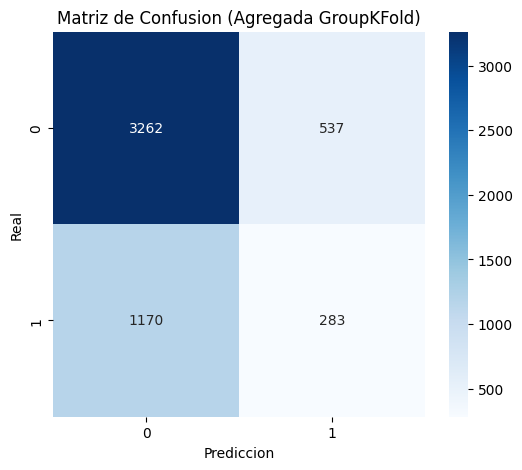

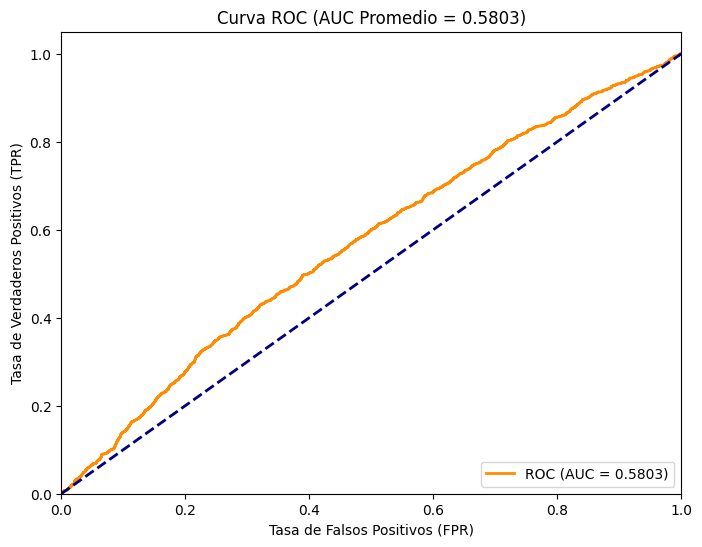

In [10]:
# ==============================================================================
# CELDA: Evaluacion Final de ExtraTreesClassifier optimizado
# Pipeline: StandardScaler -> BorderlineSMOTE -> ExtraTreesClassifier
# Embeddings: wav2vec2-large-robust
# GroupKFold usando audio_id como grupo
# ==============================================================================
EMB_MODEL = "wav2vec2-large-robust"

print(f"\n{'='*80}")
print(f"EVALUACION FINAL (GroupKFold, {N_SPLITS} folds)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: ExtraTreesClassifier (Parametros Optimizados)")
print(f"{'='*80}")

try:
    X, y, groups = load_segment_embeddings(EMBEDDINGS_ROOT, EMB_MODEL, CONDITION)
    print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
except Exception as e:
    print(f"Error cargando los embeddings: {e}")
    raise

min_samples_in_train = int(pd.Series(y).value_counts().min() * (1 - 1 / N_SPLITS))
k_safe = max(1, min(5, min_samples_in_train - 1))
m_safe = max(1, min(10, min_samples_in_train - 1))

pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', BorderlineSMOTE(random_state=42, k_neighbors=k_safe, m_neighbors=m_safe)),
    ('clf', ExtraTreesClassifier(
        random_state=42,
        class_weight='balanced',
        criterion='entropy',
        max_depth=None,
        max_features='sqrt',
        min_samples_leaf=5,
        min_samples_split=2,
        n_estimators=100,
    )),
])

classes = np.unique(y)
is_binary = len(classes) == 2

if is_binary:
    roc_scorer = 'roc_auc'
else:
    _classes_fixed = classes.tolist()

    def _roc_auc_multiclass(y_true, y_prob):
        present = np.unique(y_true)
        if len(present) < len(_classes_fixed):
            return np.nan
        try:
            return roc_auc_score(
                y_true, y_prob,
                average='macro',
                multi_class='ovr',
                labels=_classes_fixed,
            )
        except Exception:
            return np.nan

    roc_scorer = make_scorer(_roc_auc_multiclass, needs_proba=True)

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc': roc_scorer,
}

cv = GroupKFold(n_splits=N_SPLITS)

print("\nIniciando Evaluacion mediante cross_validate...")
scores = cross_validate(
    pipeline, X, y, cv=cv, scoring=scoring, groups=groups,
    n_jobs=-1, verbose=1, error_score=np.nan
)

for metric in ('test_f1_macro', 'test_accuracy', 'test_roc_auc'):
    nan_n = np.sum(np.isnan(scores[metric]))
    if nan_n > 0:
        print(f"  Aviso {metric}: {nan_n}/{len(scores[metric])} folds con NaN")

mean_f1 = np.nanmean(scores['test_f1_macro'])
std_f1 = np.nanstd(scores['test_f1_macro'])
mean_acc = np.nanmean(scores['test_accuracy'])
std_acc = np.nanstd(scores['test_accuracy'])
mean_roc = np.nanmean(scores['test_roc_auc'])
std_roc = np.nanstd(scores['test_roc_auc'])

print(f"\n{'='*80}")
print("RESULTADOS FINALES DE LA EVALUACION")
print(f"{'='*80}")
print(f"F1 Macro Promedio: {mean_f1:.4f} (±{std_f1:.4f})")
print(f"Accuracy Promedio:  {mean_acc:.4f} (±{std_acc:.4f})")
print(f"ROC AUC Promedio:   {mean_roc:.4f} (±{std_roc:.4f})")

print("\nGenerando graficos (Matriz de Confusion y Curva ROC) usando GroupKFold...")

y_prob_plot = cross_val_predict(
    pipeline, X, y, cv=cv, groups=groups, method='predict_proba', n_jobs=-1
)

y_pred_plot = np.argmax(y_prob_plot, axis=1)
classes = np.unique(y)
y_pred_plot = classes[np.argmax(y_prob_plot, axis=1)]

cm = confusion_matrix(y, y_pred_plot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusion (Agregada GroupKFold)')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

plt.figure(figsize=(8, 6))
if len(classes) == 2:
    fpr, tpr, _ = roc_curve(y, y_prob_plot[:, 1])
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {mean_roc:.4f})')
else:
    y_bin = label_binarize(y, classes=classes)
    for i, color in zip(range(len(classes)), ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']):
        if i < y_prob_plot.shape[1]:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_plot[:, i])
            roc_auc_val = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, color=color, label=f'ROC clase {classes[i]} (AUC = {roc_auc_val:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC (AUC Promedio = {mean_roc:.4f})')
plt.legend(loc='lower right')
plt.show()


EVALUACION FINAL (GroupKFold, 5 folds)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: ExtraTreesClassifier (Parametros Optimizados)

Iniciando Evaluacion mediante cross_validate...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.8s finished



RESULTADOS FINALES DE LA EVALUACION
F1 Macro Promedio: 0.5217 (±0.0546)
Accuracy Promedio:  0.6753 (±0.0478)
ROC AUC Promedio:   0.5803 (±0.0830)

Scores por fold guardados en: scores_evaluacion_final_groupkfold.csv

Generando graficos (Matriz de Confusion y Curva ROC) usando GroupKFold...


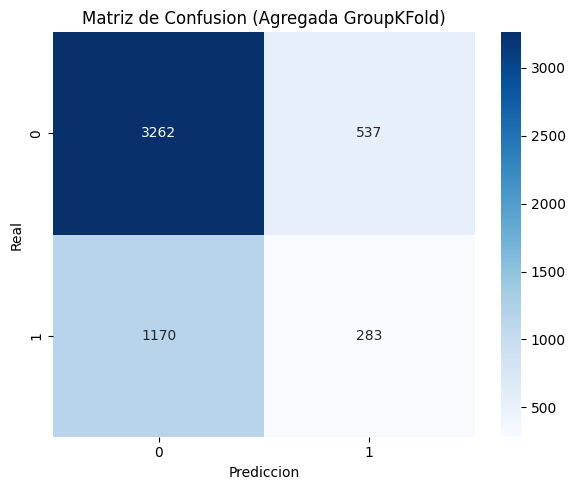

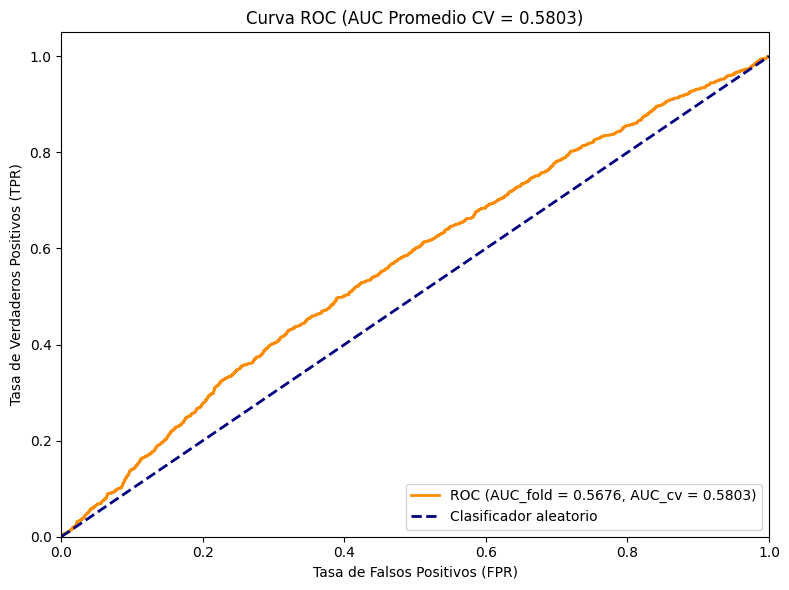

In [12]:
# ==============================================================================
# CELDA: Evaluacion Final de ExtraTreesClassifier optimizado (version extendida)
# Pipeline: StandardScaler -> BorderlineSMOTE -> ExtraTreesClassifier
# Embeddings: wav2vec2-large-robust
# GroupKFold usando audio_id como grupo
# ==============================================================================
EMB_MODEL = "wav2vec2-large-robust"

print(f"\n{'='*80}")
print(f"EVALUACION FINAL (GroupKFold, {N_SPLITS} folds)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: ExtraTreesClassifier (Parametros Optimizados)")
print(f"{'='*80}")

X, y, groups = load_segment_embeddings(EMBEDDINGS_ROOT, EMB_MODEL, CONDITION)

min_samples_in_train = int(pd.Series(y).value_counts().min() * (1 - 1 / N_SPLITS))
k_safe = max(1, min(5, min_samples_in_train - 1))
m_safe = max(1, min(10, min_samples_in_train - 1))

pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', BorderlineSMOTE(random_state=42, k_neighbors=k_safe, m_neighbors=m_safe)),
    ('clf', ExtraTreesClassifier(
        random_state=42,
        class_weight='balanced',
        criterion='entropy',
        max_depth=None,
        max_features='sqrt',
        min_samples_leaf=5,
        min_samples_split=2,
        n_estimators=100,
    )),
])

classes = np.unique(y)
is_binary = len(classes) == 2

if is_binary:
    roc_scorer = 'roc_auc'
else:
    _classes_fixed = classes.tolist()

    def _roc_auc_multiclass(y_true, y_prob):
        present = np.unique(y_true)
        if len(present) < len(_classes_fixed):
            return np.nan
        try:
            return roc_auc_score(
                y_true, y_prob,
                average='macro',
                multi_class='ovr',
                labels=_classes_fixed,
            )
        except Exception:
            return np.nan

    roc_scorer = make_scorer(_roc_auc_multiclass, needs_proba=True)

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc': roc_scorer,
}

cv = GroupKFold(n_splits=N_SPLITS)

print("\nIniciando Evaluacion mediante cross_validate...")
scores = cross_validate(
    pipeline, X, y, cv=cv, scoring=scoring, groups=groups,
    n_jobs=-1, verbose=1, error_score=np.nan
)

mean_f1 = np.nanmean(scores['test_f1_macro'])
std_f1 = np.nanstd(scores['test_f1_macro'])
mean_acc = np.nanmean(scores['test_accuracy'])
std_acc = np.nanstd(scores['test_accuracy'])
mean_roc = np.nanmean(scores['test_roc_auc'])
std_roc = np.nanstd(scores['test_roc_auc'])

roc_nan_count = np.sum(np.isnan(scores['test_roc_auc']))
total_folds = len(scores['test_roc_auc'])

print(f"\n{'='*80}")
print("RESULTADOS FINALES DE LA EVALUACION")
print(f"{'='*80}")
print(f"F1 Macro Promedio: {mean_f1:.4f} (±{std_f1:.4f})")
print(f"Accuracy Promedio:  {mean_acc:.4f} (±{std_acc:.4f})")
print(f"ROC AUC Promedio:   {mean_roc:.4f} (±{std_roc:.4f})")
if roc_nan_count > 0:
    print(
        f"  Aviso: {roc_nan_count}/{total_folds} folds produjeron NaN en ROC AUC \,(clases ausentes en test); excluidos del promedio." )

results_df = pd.DataFrame({
    'fold': range(1, len(scores['test_f1_macro']) + 1),
    'f1_macro': scores['test_f1_macro'],
    'accuracy': scores['test_accuracy'],
    'roc_auc': scores['test_roc_auc'],
})
results_df.to_csv('scores_evaluacion_final_groupkfold.csv', index=False)
print("\nScores por fold guardados en: scores_evaluacion_final_groupkfold.csv")

print("\nGenerando graficos (Matriz de Confusion y Curva ROC) usando GroupKFold...")

y_prob_all = np.zeros((len(y), len(classes)))
y_pred_all = np.empty(len(y), dtype=y.dtype)

for train_idx, test_idx in cv.split(X, y, groups=groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train = y[train_idx]

    pipeline.fit(X_train, y_train)
    y_prob_all[test_idx] = pipeline.predict_proba(X_test)
    y_pred_all[test_idx] = pipeline.predict(X_test)

cm = confusion_matrix(y, y_pred_all)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusion (Agregada GroupKFold)')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_groupkfold.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 6))

if is_binary:
    fpr, tpr, _ = roc_curve(y, y_prob_all[:, 1])
    fold_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC (AUC_fold = {fold_auc:.4f}, AUC_cv = {mean_roc:.4f})')
else:
    y_bin = label_binarize(y, classes=classes)
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']
    for i, color in zip(range(len(classes)), colors):
        if i < y_prob_all.shape[1]:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_all[:, i])
            fold_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, color=color,
                     label=f'ROC clase {classes[i]} (AUC_fold = {fold_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC (AUC Promedio CV = {mean_roc:.4f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_groupkfold.png', dpi=150)
plt.show()